# P18 — Word Embeddings from scratch  *(words become places; meaning becomes a direction)*

> **The story so far.** In P17 the mind sounded out its first words by counting — and hit a wall: to
> it, `"cat"` and `"kitten"` were as unrelated as the numbers `2` and `57`. It could read the marks
> but not feel their meaning. This chapter is where that changes, and it's the most magical turn in
> the whole story: **we give every word a place.** We scatter the vocabulary across a space and let
> the mind slide each word around until words that mean similar things end up *near* each other. Once
> words are places, **meaning becomes a direction** — the step from "man" to "woman" becomes the same
> arrow as "king" to "queen". Geometry, not lookup tables, now carries meaning.

An **embedding** represents each word as a *vector*, learned so that words used in similar contexts
land in similar spots. Then "similarity" is just nearness — cosine distance (P01 B6, the dot product
returning as the mind's sense of agreement). This is the representation every modern NLP model —
including TinyGPT (`notebooks/02`) — is built on.

We'll meet the core principle ("you shall know a word by the company it keeps"), train a tiny
**word2vec skip-gram** model from scratch with the very backprop you already know (P11) — the
heartbeat *predict → measure how wrong → step downhill*, now arranging word-places — and reproduce
the famous **`king − man + woman ≈ queen`** vector arithmetic.

## B1 — The distributional idea: meaning = context

You can guess a stranger by the company they keep, and the mind can guess a word the same way. The
foundational insight of modern NLP: **a word's meaning is captured by the words it co-occurs with.**
"Cat" and "dog" both turn up near "pet", "feed", "vet" — so if we describe each word by its
neighbours, cat and dog naturally drift close together. Embeddings learn a dense vector per word that
captures exactly this company.

We give each word a small random vector and **train** those vectors so that words sharing contexts
move together. The training signal is just "predict a word's neighbours" — no labels needed, exactly
like a GPT's self-supervision.

## B2 — Co-occurrence vectors: the distributional hypothesis, made literal

Let's make "a word is its company" completely literal. The most direct embedding: **describe each
word by the counts of the words it sits beside.** Two words that keep the same company get similar
count-vectors — so cosine similarity (P01 B6) between their rows reads off relatedness directly. No
training, no learning — just the distributional idea in its rawest, most honest form, so you can see
the magic isn't a trick of the optimizer.

We use a corpus with two themes whose context words **don't overlap** — animals keep company with
{pet, animal, fur}, royals with {royal, crown, throne}.

**Worked example by hand.** In `"cat dog pet animal fur"`, `cat` co-occurs with dog, pet, animal,
fur (each +1). Across the corpus `cat` and `dog` rack up nearly identical rows (both sit with pet,
animal, fur, and each other), while `cat` and `king` *never* co-occur → their rows are orthogonal →
cosine 0.

In [1]:
import numpy as np
from numpy.linalg import norm
sentences = [
    "cat dog pet animal fur", "dog cat animal pet fur", "pet cat dog fur animal",
    "king queen royal crown throne", "queen king throne royal crown", "royal king queen crown throne",
]
tokens = [s.split() for s in sentences]
vocab = sorted({w for s in tokens for w in s}); stoi = {w:i for i,w in enumerate(vocab)}; V = len(vocab)

# co-occurrence matrix: M[i,j] = times words i and j appear in the same sentence
M = np.zeros((V, V))
for s in tokens:
    ids = [stoi[w] for w in s]
    for a in ids:
        for b in ids:
            if a != b: M[a, b] += 1

def cos(a, b): return (a @ b) / (norm(a)*norm(b) + 1e-9)
print("vocab:", vocab)
print("\neach word's vector = its row of co-occurrence counts. cosine similarity:")
print("  cat ~ dog    :", round(cos(M[stoi['cat']],  M[stoi['dog']]),  3), " (same theme -> high)")
print("  king ~ queen :", round(cos(M[stoi['king']], M[stoi['queen']]),3), " (same theme -> high)")
print("  pet ~ animal :", round(cos(M[stoi['pet']],  M[stoi['animal']]),3))
print("  cat ~ king   :", round(cos(M[stoi['cat']],  M[stoi['king']]), 3), " (different themes -> 0)")
print("\nno one told the model what a cat IS — similarity emerged purely from shared company.")

vocab: ['animal', 'cat', 'crown', 'dog', 'fur', 'king', 'pet', 'queen', 'royal', 'throne']

each word's vector = its row of co-occurrence counts. cosine similarity:
  cat ~ dog    : 0.75  (same theme -> high)
  king ~ queen : 0.75  (same theme -> high)
  pet ~ animal : 0.75
  cat ~ king   : 0.0  (different themes -> 0)

no one told the model what a cat IS — similarity emerged purely from shared company.


The animals cluster, the royals cluster, and the two themes are orthogonal — the distributional
hypothesis working with nothing but counts. Real embeddings just **compress** this giant
co-occurrence matrix into a small dense vector — which is exactly what skip-gram does next.

## B3 — Skip-gram: the neural, compressed version (word2vec)

The count matrix works, but it's enormous and sparse — one column per word in the language. The mind
wants a *compressed* place for each word: a short vector that still remembers the company. Enter
**word2vec skip-gram**, which learns the same thing with a tiny neural net instead of a giant count
table. It slides a window over text and, for each **centre** word, plays a guessing game — **predict
its neighbours** — and nudges the word-places (the heartbeat again: predict → measure → step
downhill) until the guesses are good:
```
score(o | c) = v_out[o] · v_in[c]        (dot product, P01)
P(o | c)     = softmax over all words    (Notebook 00 B6)
loss         = −ln P(true neighbour)     (cross-entropy, P03)  -> gradient (p − onehot), as in P07
```
The learned `v_in` vectors are the embeddings. We train it, then check it learned by asking: *which
neighbours does it now predict for `cat`?* (They should be the animal-theme words.) On a real corpus
the `v_in` cosine similarities reproduce B2's structure; on a 10-word toy corpus the **prediction
behaviour** is the cleaner thing to inspect.

In [2]:
import numpy as np
rng = np.random.default_rng(0)
sentences = ["cat dog pet animal fur","dog cat animal pet fur","pet cat dog fur animal",
             "king queen royal crown throne","queen king throne royal crown","royal king queen crown throne"]
tokens=[s.split() for s in sentences]; vocab=sorted({w for s in tokens for w in s})
stoi={w:i for i,w in enumerate(vocab)}; itos={i:w for w,i in stoi.items()}; V=len(vocab)
WINDOW=4; pairs=[]
for s in tokens:
    ids=[stoi[w] for w in s]
    for i,c in enumerate(ids):
        for j in range(max(0,i-WINDOW), min(len(ids), i+WINDOW+1)):
            if j!=i: pairs.append((c,ids[j]))

D=10; Win=rng.normal(0,0.5,(V,D)); Wout=rng.normal(0,0.5,(V,D)); lr=0.1
def softmax(z): z=z-z.max(); e=np.exp(z); return e/e.sum()
for epoch in range(500):
    rng.shuffle(pairs)
    for c,o in pairs:
        p=softmax(Wout@Win[c])           # predicted neighbour distribution
        p[o]-=1                          # cross-entropy gradient = (p - onehot)  (P03/P07)
        gi=Wout.T@p
        Wout-=lr*np.outer(p,Win[c]); Win[c]-=lr*gi
print("trained skip-gram (%d-dim) for %d words.\n" % (D, V))

def top_neighbours(word, k=3):
    p = softmax(Wout @ Win[stoi[word]])
    order = np.argsort(p)[::-1]
    return [itos[i] for i in order if itos[i] != word][:k]
print("skip-gram's top predicted neighbours:")
print("  for 'cat'  ->", top_neighbours("cat"),  " (animal-theme words)")
print("  for 'king' ->", top_neighbours("king"), " (royal-theme words)")
print("it learned each word's company — the same signal B2 counted, now compressed into vectors.")

trained skip-gram (10-dim) for 10 words.

skip-gram's top predicted neighbours:
  for 'cat'  -> ['animal', 'dog', 'pet']  (animal-theme words)
  for 'king' -> ['queen', 'crown', 'throne']  (royal-theme words)
it learned each word's company — the same signal B2 counted, now compressed into vectors.


## B4 — Vector arithmetic: `king − man + woman ≈ queen`

Now the payoff that made the world sit up. Once words are places, **relationships are directions you
can walk.** The little arrow that takes you from "man" to "woman" turns out to be the *same* arrow
that takes you from "king" to "queen" — a "gender" direction baked into the space. So you can do
arithmetic *on meaning*:
```
king − man + woman ≈ queen
```
We demonstrate the *mechanism* with hand-built 2-D vectors so the arithmetic is exact and visible
(real embeddings learn this from data, as in B2, but need a big corpus to nail analogies).

**Worked example by hand.** Place:
```
man=[1,0]  woman=[1,2]  king=[4,0]  queen=[4,2]
king − man + woman = [4,0] − [1,0] + [1,2] = [4, 2] = queen   ✓
```

In [3]:
import numpy as np
from numpy.linalg import norm
emb = {"man":np.array([1.,0.]), "woman":np.array([1.,2.]),
       "king":np.array([4.,0.]), "queen":np.array([4.,2.])}
result = emb["king"] - emb["man"] + emb["woman"]
print("king - man + woman =", result, " (hand [4,2])")

def closest(vec):
    return max(emb, key=lambda w: (vec@emb[w])/(norm(vec)*norm(emb[w])+1e-9))
print("closest word to the result:", closest(result), " <- queen!")
print("\nthe 'gender' direction (woman-man) added to king lands on queen — relationships are geometry.")

king - man + woman = [4. 2.]  (hand [4,2])
closest word to the result: queen  <- queen!

the 'gender' direction (woman-man) added to king lands on queen — relationships are geometry.


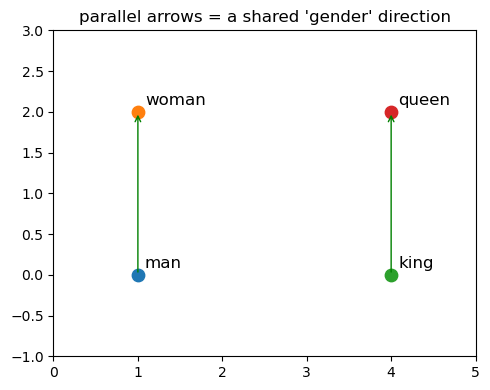

the two green arrows are parallel -> king:queen relate just like man:woman.


In [4]:
import numpy as np, matplotlib.pyplot as plt
emb = {"man":[1,0],"woman":[1,2],"king":[4,0],"queen":[4,2]}
plt.figure(figsize=(5,4))
for w,(x,y) in emb.items():
    plt.scatter(x,y,s=80); plt.annotate(w,(x,y),fontsize=12,xytext=(5,5),textcoords="offset points")
# draw the parallel "gender" arrows
plt.annotate("",xy=(1,2),xytext=(1,0),arrowprops=dict(arrowstyle="->",color="green"))
plt.annotate("",xy=(4,2),xytext=(4,0),arrowprops=dict(arrowstyle="->",color="green"))
plt.title("parallel arrows = a shared 'gender' direction"); plt.xlim(0,5); plt.ylim(-1,3)
plt.tight_layout(); plt.show()
print("the two green arrows are parallel -> king:queen relate just like man:woman.")

## B5 — Connection to the GPT's embedding table

Everything you just built is the mind's front door in a real GPT. This is exactly
`notebooks/02_Embeddings`. A GPT's **embedding table** is a `(vocab_size × embedding_dim)` matrix —
one learned place per token (Notebook 00 B7). It starts random and, during
training, the rows arrange themselves so related tokens are nearby — the same outcome as word2vec,
but learned *jointly* with the rest of the model rather than as a separate step. word2vec gives a
fixed vector per word; a transformer goes further and makes each token's representation
**context-dependent** via attention (the same word gets different vectors in different sentences).
That upgrade is the subject of Part 4.

In [5]:
import torch, torch.nn as nn
# a GPT-style embedding table: lookup, exactly as in Notebook 00 B7
vocab_size, d_model = 6, 8
emb = nn.Embedding(vocab_size, d_model)
tokens = torch.tensor([0, 3, 1])          # a sequence of token ids
vecs = emb(tokens)                         # row lookup -> (3, 8)
print("embedding table shape:", tuple(emb.weight.shape), " (one row per token)")
print("look up tokens", tokens.tolist(), "-> vectors shape", tuple(vecs.shape))
print("these rows START random and are LEARNED by backprop, like word2vec but jointly with the model.")

embedding table shape: (6, 8)  (one row per token)
look up tokens [0, 3, 1] -> vectors shape (3, 8)
these rows START random and are LEARNED by backprop, like word2vec but jointly with the model.


## Recap — embeddings

| Idea | What | Where |
|------|------|-------|
| Distributional hypothesis | meaning = context company | B1 |
| Skip-gram | predict neighbours; dot-product score | B2 |
| Cosine similarity | measure relatedness (P01) | B2 |
| Vector arithmetic | relationships = directions | B3 |
| GPT embedding table | learned row per token | B4, `notebooks/02` |

## Common mistakes
1. **Tiny corpus, big expectations.** Good analogies need lots of text; our demo shows the *mechanism*, not production quality.
2. **Comparing embeddings by raw dot product** when vectors differ in length — use cosine similarity (P01 B6).
3. **Confusing the two weight matrices** in skip-gram (`Win` centre vs `Wout` context) — we keep `Win` as the embeddings.
4. **Thinking word2vec vectors are context-aware.** They're fixed per word; transformers make them context-dependent (Part 4).
5. **Forgetting embeddings are learned.** They're not hand-assigned meanings — backprop arranges them.

## Exercises (do them in new code cells)
1. In B2, add a sentence `"fish cat dog pet animal"`. Does `fish` end up near `cat`/`dog`? Why?
2. Compute `cos(cat, pet)` after training. Is it higher than `cos(cat, king)`? Should it be?
3. Build a hand 2-D analogy for `paris − france + italy ≈ rome`. Choose coordinates that make it exact.
4. Increase `D` (embedding dim) from 8 to 2 in B2. Do the similarities get better or worse, and why?
5. Explain why a transformer's contextual embedding can give `"bank"` two different vectors in "river bank" vs "bank account", while word2vec cannot.

---

**Words are now places, and meaning is a direction the mind can walk.** But each word still gets just
*one* fixed place — "bank" sits in a single spot whether you mean a river or a vault. To read for
real, the mind must let a word's meaning *shift with its sentence* — and to do that, it must learn to
look back at the other words and decide which ones matter. Next, in
[P19 — Seq2Seq & the birth of Attention](P19_Seq2Seq_and_Attention.ipynb), translation pushes the
old memory to its breaking point, and out of that pressure **the mind learns to pay attention** —
the mechanism that leads straight to the transformer.